In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 36.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
!pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.9 MB/s eta 0:00:00


In [4]:
from chembl_webresource_client.new_client import new_client

target = new_client.target
result = target.search('EGFR')

for t in result[:3]:
    print(t['target_chembl_id'], t['pref_name'])

CHEMBL4523747 EGFR/PPP1CA
CHEMBL5465557 CCN2-EGFR
CHEMBL3608 Epidermal growth factor receptor


In [5]:
activity = new_client.activity
data = activity.filter(target_chembl_id='CHEMBL3608', standard_type='IC50')

df = pd.DataFrame.from_records(data)
print(df.shape)
print(df.head())

(107, 47)
  action_type activity_comment  activity_id activity_properties  \
0        None             None       110221                  []   
1        None             None       110221                  []   
2        None             None       113118                  []   
3        None             None       119387                  []   
4        None             None       133319                  []   

  assay_chembl_id                                  assay_description  \
0    CHEMBL675511  Inhibition of epidermal growth factor receptor...   
1    CHEMBL675511  Inhibition of epidermal growth factor receptor...   
2    CHEMBL675511  Inhibition of epidermal growth factor receptor...   
3    CHEMBL675511  Inhibition of epidermal growth factor receptor...   
4    CHEMBL675511  Inhibition of epidermal growth factor receptor...   

  assay_type assay_variant_accession assay_variant_mutation bao_endpoint  ...  \
0          B                    None                   None  BAO_0000190 

In [6]:
print(df.columns.tolist())

['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'modality', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value']


In [7]:
df2 = df[['molecule_chembl_id', 'canonical_smiles', 'standard_value']].dropna()
print(df2.shape)
print(df2.head())

(104, 3)
  molecule_chembl_id                                   canonical_smiles  \
0       CHEMBL292323  COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...   
1       CHEMBL292323  COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...   
2       CHEMBL304414  Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...   
3        CHEMBL62176                 CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21   
4        CHEMBL62701  Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...   

  standard_value  
0       100000.0  
1       100000.0  
2       100000.0  
3       100000.0  
4        25000.0  


In [9]:
df2['standard_value'] = pd.to_numeric(df2['standard_value'], errors='coerce')
df2 = df2.dropna(subset=['standard_value'])

df2['activity'] = df2['standard_value'].apply(lambda x: 1 if x <= 1000 else 0)

print(df2['activity'].value_counts())

activity
0    71
1    33
Name: count, dtype: int64


In [10]:
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
        return np.array(fp)
    else:
        return None

df2['fingerprint'] = df2['canonical_smiles'].apply(smiles_to_fingerprint)
df2 = df2.dropna(subset=['fingerprint'])

print("Done! Shape:", df2.shape)

Done! Shape: (104, 5)


[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerator
[07:30:46] DEPRECATION WARNING: please use MorganGenerat

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = np.stack(df2['fingerprint'].values)
y = df2['activity'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 95.24 %


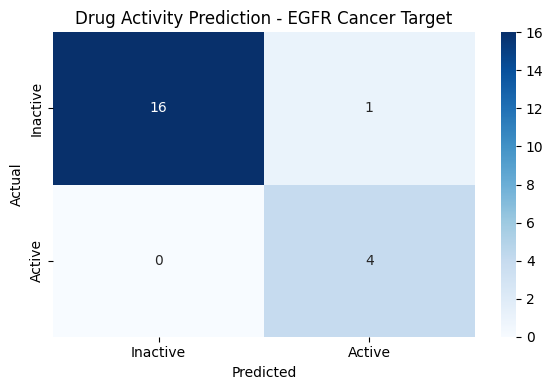

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
plt.title('Drug Activity Prediction - EGFR Cancer Target')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

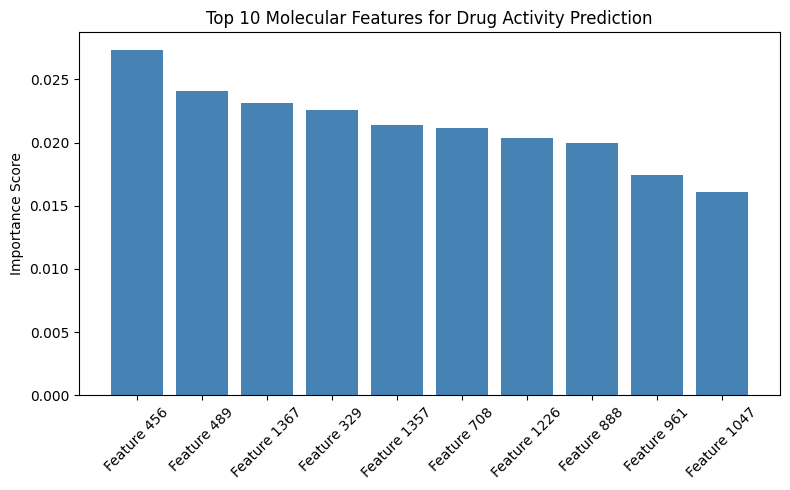

In [13]:
importances = model.feature_importances_
top_indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,5))
plt.bar(range(10), importances[top_indices], color='steelblue')
plt.xticks(range(10), [f'Feature {i}' for i in top_indices], rotation=45)
plt.title('Top 10 Molecular Features for Drug Activity Prediction')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()